##Cell 1 — Config + imports

In [ ]:
import os
import json
import re
from collections import Counter , defaultdict
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive

In [ ]:
import os
import json
import pandas as pd
from google.colab import drive

drive.mount('/content/drive')

BASE_PATH = "/content/drive/MyDrive/Transcripts_CSS"

COMMUNITIES = [
    "transcripts_business",
    "transcripts_religion",
    "transcripts_comedy",
    "transcripts_lifestyle",
    "transcripts_tech",
    "transcripts_motivational",
    "transcripts_gaming",
    "transcripts_politics",
]

records = []
error_files = []

for community in COMMUNITIES:
    folder_path = os.path.join(BASE_PATH, community)
    if not os.path.isdir(folder_path):
        print(f"WARNING: folder not found, skipping: {folder_path}")
        continue

    for root, dirs, files in os.walk(folder_path):
        for file in files:
            if file.endswith(".json"):
                full_path = os.path.join(root, file)
                try:
                    with open(full_path, encoding="utf-8") as f:
                        data = json.loads(f.read())

                    video_id = data.get("filename", file)
                    whisperx_lang = data.get("language", "unknown")

                    records.append({
                        "video_id": video_id,
                        "community": community,
                        "whisperx_language": whisperx_lang,
                    })

                except Exception as e:
                    error_files.append((full_path, str(e)))

print(f"Total JSON files processed: {len(records)}")
print(f"Files with errors: {len(error_files)}")

df = pd.DataFrame(records)
print(df.shape)

Mounted at /content/drive
Total JSON files processed: 9996
Files with errors: 0
(9996, 3)


##Cell 2 — Helper functions

In [ ]:
def get_text(dictionary):
    text = ""
    for seg in dictionary.get("segments", []):
        text += seg.get("text", "")
    return text.strip()

def classify_script(text, whisperx_lang, dev_thresh=0.9, latin_thresh=0.9,
                     mix_floor=0.05, other_dominant=0.5):
    """
    Classifies a transcript into: noise, hindi, english,
    hindi-english (code-mixed), other, or unknown/no_text.
    """
    # WhisperX artifact: nn (Nynorsk) shows up on noisy/low-signal audio,
    # not genuine Norwegian speech — treat as noise, not "other language"
    if whisperx_lang == "nn":
        return "noise"

    devanagari_chars = sum(1 for c in text if '\u0900' <= c <= '\u097F')
    latin_chars = sum(1 for c in text if c.isascii() and c.isalpha())
    other_chars = sum(1 for c in text if c.isalpha() and not c.isascii()
                       and not ('\u0900' <= c <= '\u097F'))

    total = devanagari_chars + latin_chars + other_chars
    if total == 0:
        return "unknown/no_text"

    dev_pct = devanagari_chars / total
    latin_pct = latin_chars / total
    other_pct = other_chars / total

    if other_pct >= other_dominant:
        return "other"
    elif dev_pct >= dev_thresh:
        return "hindi"
    elif latin_pct >= latin_thresh:
        return "english"
    elif dev_pct >= mix_floor and latin_pct >= mix_floor:
        return "hindi-english (code-mixed)"
    else:
        return "other"

##Cell 3 — Walk ALL 8 communities (this is the slow one — run once, keep result)

In [ ]:
records = []
error_files = []
whisperx_lang_dict = Counter()
script_class_dict = Counter()
per_community_class = defaultdict(Counter)

for community in COMMUNITIES:
    folder_path = os.path.join(BASE_PATH, community)
    if not os.path.isdir(folder_path):
        print(f"WARNING: folder not found, skipping: {folder_path}")
        continue

    for root, dirs, files in os.walk(folder_path):
        for file in files:
            if file.endswith(".json"):
                full_path = os.path.join(root, file)
                try:
                    with open(full_path, encoding="utf-8") as f:
                        data = json.loads(f.read())

                    video_id = data.get("filename", file)
                    whisperx_lang = data.get("language", "unknown")
                    text = get_text(data)
                    script_class = classify_script(text, whisperx_lang)

                    whisperx_lang_dict[whisperx_lang] += 1
                    script_class_dict[script_class] += 1
                    per_community_class[community][script_class] += 1

                    record = {
                        "video_id": video_id,
                        "community": community,
                        "whisperx_language": whisperx_lang,
                        "script_class": script_class,
                        "transcript_length_chars": len(text),
                        "file_path": full_path,
                    }
                    records.append(record)

                except Exception as e:
                    error_files.append((full_path, str(e)))

print(f"Total JSON files processed: {len(records)}")
print(f"Files with errors: {len(error_files)}")
if error_files:
    print("First few errors:", error_files[:5])

Total JSON files processed: 9996
Files with errors: 0


##full language breakdown per community


In [ ]:
import pandas as pd

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

# df must already exist from the walk cell, with 'community' and 'whisperx_language' columns
lang_breakdown = pd.crosstab(df["community"], df["whisperx_language"])

# add a row totals column and sort columns by overall frequency (most common language first)
lang_breakdown["TOTAL"] = lang_breakdown.sum(axis=1)
col_order = lang_breakdown.drop(columns="TOTAL").sum().sort_values(ascending=False).index.tolist()
lang_breakdown = lang_breakdown[col_order + ["TOTAL"]]

print(lang_breakdown.to_string())

# lang_breakdown.to_csv("./csv/full_language_breakdown_per_community.csv")

whisperx_language           hi   en   ur   sa  nn  ta  ar  zh  sv  ml  pa  mr  te  km  ru  jw  bn  mn  kn  ne  pt  ko  la  cy  es  haw  tr  da  ja  bo  sd  uk  unknown  vi  TOTAL
community                                                                                                                                                                         
transcripts_business       830  306    0    0  12   1   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   2   0   0   0    0   0   0   0   0   0   0        0   0   1151
transcripts_comedy         924  127    5    0   3   2   0   6   0   1   1   0   5   1   2   4   0   0   1   1   0   0   0   0   0    0   1   0   0   0   0   0        0   0   1084
transcripts_gaming         830  311   12    1  36   0   0   5   0   0   3   0   4   7   1   0   0   2   0   0   2   1   1   0   2    1   0   0   1   0   0   0        0   1   1221
transcripts_lifestyle      866  247    0    0   1   0   0   0   0   0   0   1   0   1   2   0   0   0   0

##Cell 4 — Summary stats

In [ ]:
df_all = pd.DataFrame(records)

print("--- Overall script-based classification ---")
print(dict(script_class_dict))
print()
print("--- Overall WhisperX/AI4Bharat raw tag distribution (top 15) ---")
print(dict(whisperx_lang_dict.most_common(15)))
print()

print("--- Per-community breakdown ---")
per_community_df = pd.DataFrame(per_community_class).fillna(0).astype(int).T
print(per_community_df)

os.makedirs("./csv", exist_ok=True)
df_all.to_csv("./csv/eda_language_all_communities.csv", index=False)
per_community_df.to_csv("./csv/eda_language_per_community.csv")

--- Overall script-based classification ---
{'english': 2363, 'hindi-english (code-mixed)': 4071, 'hindi': 3027, 'noise': 81, 'other': 445, 'unknown/no_text': 9}

--- Overall WhisperX/AI4Bharat raw tag distribution (top 15) ---
{'hi': 6959, 'en': 2283, 'ur': 326, 'sa': 145, 'nn': 81, 'ta': 43, 'ar': 24, 'zh': 13, 'pa': 12, 'sv': 12, 'ml': 12, 'mr': 11, 'te': 11, 'km': 11, 'ru': 9}

--- Per-community breakdown ---
                          english  hindi-english (code-mixed)  hindi  noise  \
transcripts_business          306                         683    147     12   
transcripts_religion          378                         110    597     19   
transcripts_comedy            131                         507    428      3   
transcripts_lifestyle         247                         402    466      1   
transcripts_tech              437                         866    131      5   
transcripts_motivational      317                         473    301      1   
transcripts_gaming            

##Cell 5 — Plot: overall distribution

/tmp/ipykernel_764/1071172867.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=plot_df, x="class", y="count", palette="colorblind")


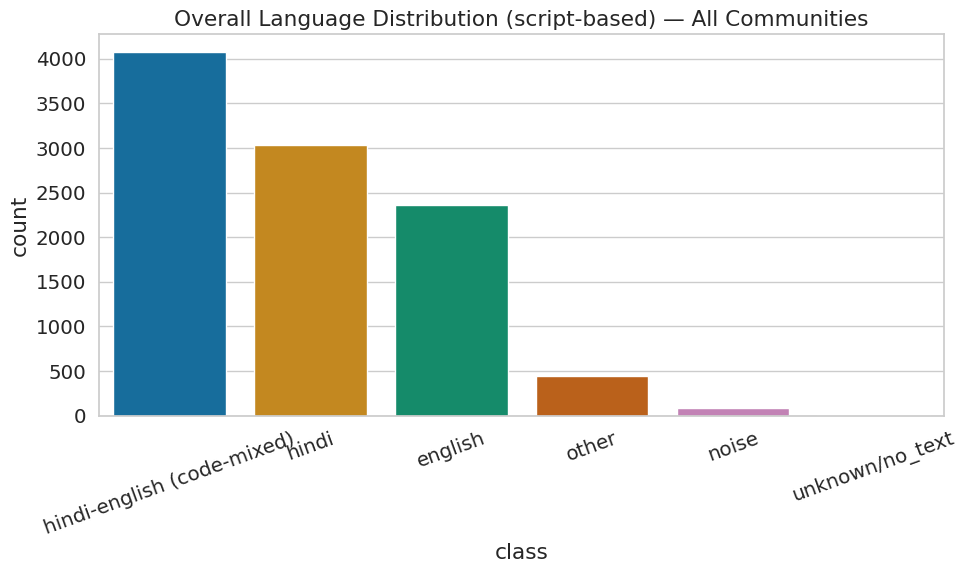

In [ ]:
plt.rcParams['figure.figsize'] = 10, 6
sns.set(font_scale=1.3)
sns.set_style("whitegrid")

plot_df = df_all["script_class"].value_counts().reset_index()
plot_df.columns = ["class", "count"]

ax = sns.barplot(data=plot_df, x="class", y="count", palette="colorblind")
ax.set_title("Overall Language Distribution (script-based) — All Communities")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("./csv/overall_language_distribution.png", dpi=150)
plt.show()

##Cell 6 — Plot: per-community stacked bar

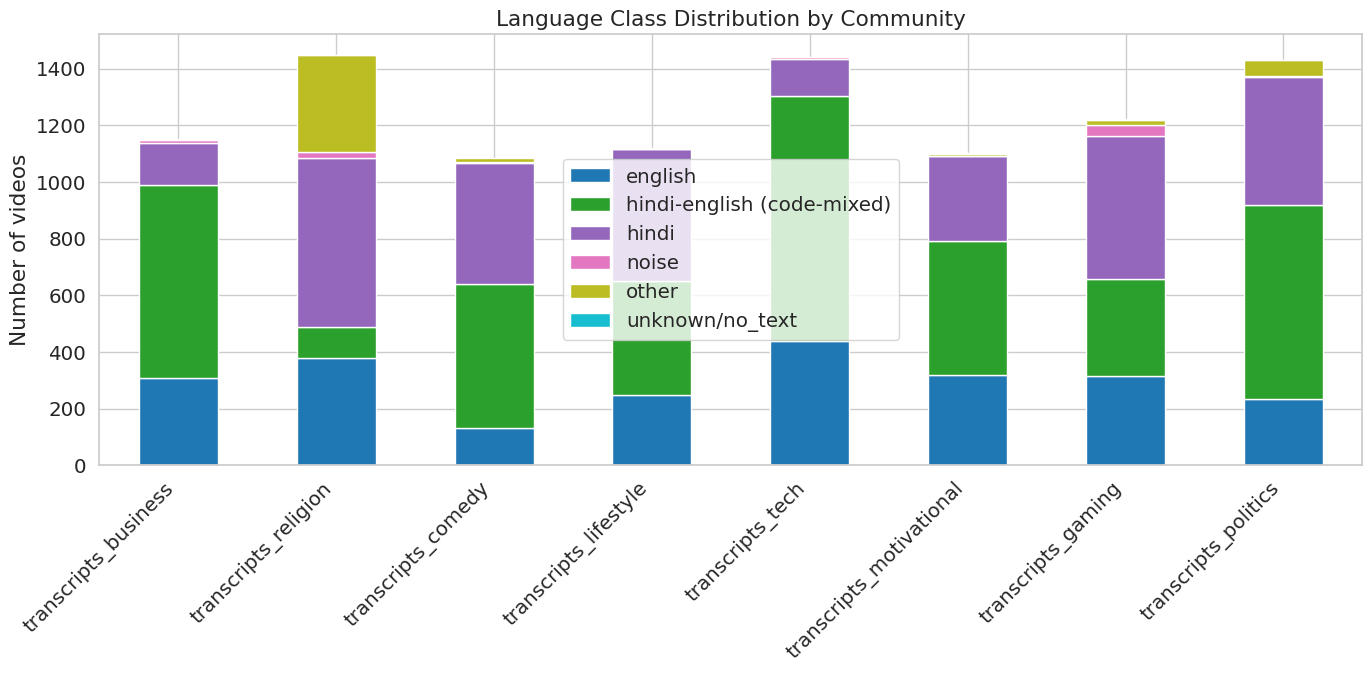

In [ ]:
plt.rcParams['figure.figsize'] = 14, 7
ax = per_community_df.plot(kind="bar", stacked=True, colormap="tab10")
ax.set_title("Language Class Distribution by Community")
ax.set_ylabel("Number of videos")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("./csv/per_community_language_distribution.png", dpi=150)
plt.show()

## Save all data

In [ ]:
import os

OUTPUT_DIR = "/content/drive/MyDrive/Transcripts_CSS/outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Saving all outputs to: {OUTPUT_DIR}")

Saving all outputs to: /content/drive/MyDrive/Transcripts_CSS/outputs


In [ ]:
# --- Summary stats ---
df_all.to_csv(os.path.join(OUTPUT_DIR, "eda_language_all_communities.csv"), index=False)
per_community_df.to_csv(os.path.join(OUTPUT_DIR, "eda_language_per_community.csv"))

# --- Overall distribution plot ---
# (run this right after the plt.show() call in your overall distribution plot cell)
plt.savefig(os.path.join(OUTPUT_DIR, "overall_language_distribution.png"), dpi=150)

# --- Per-community stacked bar plot ---
# (run this right after the plt.show() call in your per-community plot cell)
plt.savefig(os.path.join(OUTPUT_DIR, "per_community_language_distribution.png"), dpi=150)

# --- Keep/exclude lists ---
KEEP_CLASSES = ["english", "hindi", "hindi-english (code-mixed)"]
df_all["keep_for_project"] = df_all["script_class"].isin(KEEP_CLASSES)

kept_df = df_all[df_all["keep_for_project"]]
excluded_df = df_all[~df_all["keep_for_project"]]

kept_df.to_csv(os.path.join(OUTPUT_DIR, "kept_hindi_english_videos.csv"), index=False)
excluded_df.to_csv(os.path.join(OUTPUT_DIR, "excluded_other_videos.csv"), index=False)

print(f"Kept (English/Hindi/code-mixed): {len(kept_df)}")
print(f"Excluded (other/unknown/noise): {len(excluded_df)}")
print("Excluded breakdown:")
print(excluded_df["script_class"].value_counts())

# --- Full language breakdown ---
lang_breakdown = pd.crosstab(df_all["community"], df_all["whisperx_language"])
lang_breakdown["TOTAL"] = lang_breakdown.sum(axis=1)
col_order = lang_breakdown.drop(columns="TOTAL").sum().sort_values(ascending=False).index.tolist()
lang_breakdown = lang_breakdown[col_order + ["TOTAL"]]
lang_breakdown.to_csv(os.path.join(OUTPUT_DIR, "full_language_breakdown_per_community.csv"))

Kept (English/Hindi/code-mixed): 9461
Excluded (other/unknown/noise): 535
Excluded breakdown:
script_class
other              445
noise               81
unknown/no_text      9
Name: count, dtype: int64


<Figure size 1400x700 with 0 Axes>

## Noise/Other?Unknown files indentification to move

In [ ]:
import shutil

MOVED_FOLDER = os.path.join(BASE_PATH, "noise_and_other_transcripts")
MOVE_CLASSES = ["noise", "other", "unknown/no_text"]

to_move_df = df_all[df_all["script_class"].isin(MOVE_CLASSES)].copy()

print(f"Files to move: {len(to_move_df)}")
print(to_move_df["script_class"].value_counts())
print()
print(to_move_df[["community", "video_id", "script_class"]].head(20))

Files to move: 535
script_class
other              445
noise               81
unknown/no_text      9
Name: count, dtype: int64

                 community                           video_id script_class
111   transcripts_business  LabourLawAdvisor__hjpna_RKXMA.mp3        noise
176   transcripts_business   CARachanaRanade__rznabG0CRJ8.mp3        noise
733   transcripts_business       UjjwalPatni__LXr-fbH9bP8.mp3        other
794   transcripts_business      NikhilKamath__0YKTsHr5bDE.mp3        other
800   transcripts_business      NikhilKamath__68ylaeBbdsg.mp3        noise
806   transcripts_business      NikhilKamath__JAgHUDhaTU0.mp3        noise
813   transcripts_business      NikhilKamath__O7O204wD82s.mp3        noise
814   transcripts_business      NikhilKamath__QT2FGbR0nIM.mp3        noise
816   transcripts_business      NikhilKamath__Rni7Fz7208c.mp3        noise
825   transcripts_business      NikhilKamath__YqdJSu1DX48.mp3        noise
826   transcripts_business      NikhilKamath__c

In [ ]:
DRY_RUN = True  # keep True until you've reviewed the printout below

os.makedirs(MOVED_FOLDER, exist_ok=True)

planned_moves = []
for _, row in to_move_df.iterrows():
    community = row["community"]
    src = row["file_path"]
    file_name = os.path.basename(src)

    dest_dir = os.path.join(MOVED_FOLDER, community)
    dest_path = os.path.join(dest_dir, file_name)

    planned_moves.append((src, dest_path))

print(f"Planned moves: {len(planned_moves)}")
for src, dest in planned_moves[:10]:
    print(f"  {src}\n    -> {dest}")
print("  ...")

if DRY_RUN:
    print("\nDRY_RUN is True — no files were moved. Review above, then set DRY_RUN = False and rerun Cell 10.")

Planned moves: 535
  /content/drive/MyDrive/Transcripts_CSS/transcripts_business/LabourLawAdvisor__hjpna_RKXMA.json
    -> /content/drive/MyDrive/Transcripts_CSS/noise_and_other_transcripts/transcripts_business/LabourLawAdvisor__hjpna_RKXMA.json
  /content/drive/MyDrive/Transcripts_CSS/transcripts_business/CARachanaRanade__rznabG0CRJ8.json
    -> /content/drive/MyDrive/Transcripts_CSS/noise_and_other_transcripts/transcripts_business/CARachanaRanade__rznabG0CRJ8.json
  /content/drive/MyDrive/Transcripts_CSS/transcripts_business/UjjwalPatni__LXr-fbH9bP8.json
    -> /content/drive/MyDrive/Transcripts_CSS/noise_and_other_transcripts/transcripts_business/UjjwalPatni__LXr-fbH9bP8.json
  /content/drive/MyDrive/Transcripts_CSS/transcripts_business/NikhilKamath__0YKTsHr5bDE.json
    -> /content/drive/MyDrive/Transcripts_CSS/noise_and_other_transcripts/transcripts_business/NikhilKamath__0YKTsHr5bDE.json
  /content/drive/MyDrive/Transcripts_CSS/transcripts_business/NikhilKamath__68ylaeBbdsg.json


In [ ]:
DRY_RUN = False  # confirm you've checked the dry run output first

moved_count = 0
error_moves = []

for src, dest in planned_moves:
    try:
        os.makedirs(os.path.dirname(dest), exist_ok=True)

        if not os.path.exists(src):
            error_moves.append((src, "source file no longer exists"))
            continue

        shutil.move(src, dest)
        moved_count += 1

    except Exception as e:
        error_moves.append((src, str(e)))

print(f"Moved: {moved_count} files")
print(f"Errors: {len(error_moves)}")
if error_moves:
    print("First few errors:")
    for src, err in error_moves[:5]:
        print(f"  {src}: {err}")

Moved: 535 files
Errors: 0


In [ ]:
to_move_df.to_csv(os.path.join(OUTPUT_DIR, "moved_noise_other_manifest.csv"), index=False)
print(f"Manifest saved with {len(to_move_df)} entries.")

Manifest saved with 535 entries.


In [ ]:
verify_records = []
for community in COMMUNITIES:
    folder_path = os.path.join(BASE_PATH, community)
    if not os.path.isdir(folder_path):
        continue

    for root, dirs, files in os.walk(folder_path):
        for file in files:
            if file.endswith(".json"):
                full_path = os.path.join(root, file)
                try:
                    with open(full_path, encoding="utf-8") as f:
                        data = json.loads(f.read())

                    whisperx_lang = data.get("language", "unknown")
                    text = get_text(data)
                    script_class = classify_script(text, whisperx_lang)

                    verify_records.append({
                        "video_id": data.get("filename", file),
                        "community": community,
                        "script_class": script_class,
                        "file_path": full_path,
                    })
                except Exception as e:
                    print(f"Error reading {full_path}: {e}")

verify_df = pd.DataFrame(verify_records)

print(f"Total files remaining in original community folders: {len(verify_df)}")
print(verify_df["script_class"].value_counts())
print()

leftover_bad = verify_df[verify_df["script_class"].isin(MOVE_CLASSES)]
if len(leftover_bad) == 0:
    print("PASS: No noise/other/unknown files remain in original community folders.")
else:
    print(f"WARNING: {len(leftover_bad)} noise/other/unknown files still present:")
    print(leftover_bad[["community", "video_id", "script_class", "file_path"]])

Total files remaining in original community folders: 9461
script_class
hindi-english (code-mixed)    4071
hindi                         3027
english                       2363
Name: count, dtype: int64

PASS: No noise/other/unknown files remain in original community folders.
